# Image processing, pt 2/3

# The data



In [1]:
# Libraries

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
# Library to load tiff files
import tifffile as tiff
# General math libraries
import numpy as np
from scipy import stats
# Image analysis libraries/modules
import skimage as sk
from scipy import ndimage

## Tracking a kinase translocation reporter (KTR)

To assess the activity of kinases in single live cells, which can e.g. activate and deactivate proteins, researchers have developed kinase translocation reporters (KTRs). These are fluorescently tagged proteins (or protein domains) whose location inside the cell changes (translocates) depending on whether a specific kinase is active (see also figure 1 of [Kudo et al.](http://doi.org/10.1038/nprot.2017.128)).

The paper [Chavez-Abiega et al.](http://doi.org/10.1242/jcs.259685) presents an image analysis pipeline to analyze KTR signals from single cells (and uses it to study kinase behavior). We'll use their data, and try to reproduce part of that analysis.

<img src=figures/kudo_fig1b_extendedmw.png height=350>

*Diagram (left) and Fig 1b of Kudo et al. (right). When kinase activity is high, KTRs predominantly localize to the cytoplasm due to reduced nuclear localization signal and increased nuclear export signal, and vice versa.*

### Example of data analysis

<img src=figures/KTR_ratios_ch1_overtime_Chavez-Abiega.png width=25%>

**Figure above.** The data contain many timepoints. After observing the cells for some time, a stimulant was added (blue line) that activated a kinase was added.
This is reflected by the fact that the ratio of cytoplasmic fluorescent intensity (C) over the nuclear fluorescent intensity (N) of the KTR sensor increases.

### Loading KTR data

We do this the same way as before, but now we also load 
the intensity data from the KTR sensor, which is 
stored in the 3rd (`i=2`) channel.

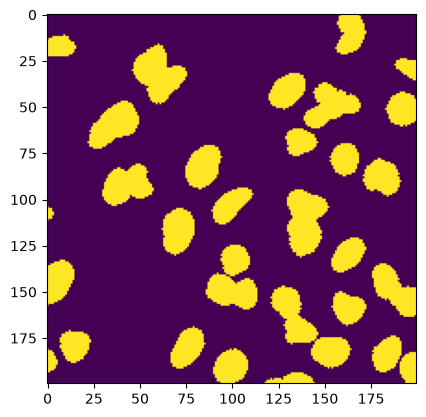

In [2]:
# Obtain data
img_nuclei = tiff.imread("images/KTR_t0.tif")[0,:,:]
img_KTR    = tiff.imread("images/KTR_t0.tif")[2,:,:]

# Let's get our nuclei mask again using triangle method
thresh_triangle = sk.filters.threshold_triangle(img_nuclei)
mask_nuclei = img_nuclei > thresh_triangle
mask_nuclei_clean = sk.morphology.opening(mask_nuclei, footprint=sk.morphology.disk(3))

_ = plt.imshow(mask_nuclei_clean[0:200,0:200])

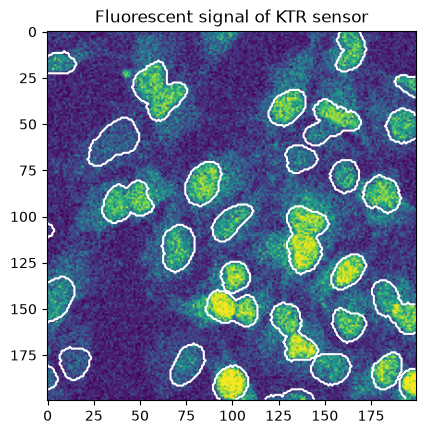

In [3]:
_ = plt.title("Fluorescent signal of KTR sensor")
_ = plt.imshow(img_KTR[0:200,0:200])
_ = plt.contour(mask_nuclei_clean[0:200,0:200], colors="w")

# Data analysis aims

We're going to reproduce a small part of the analysis. 

Specifically, we want to be able to:
- Identify the nuclei
- Identify representative cytoplasm
- Calculate intensity ratios

# Background processing and correction

When calculating ratios, a background signal has an undesired contribution to the calculated ratio.

As this is the case, we want to subtract the background from the intensity image.

## Different approaches for different challenges

- Globally uniform background
    - Correct with a constant
    - Common approaches: use the mode, average of known background region.
- Spatially varying background
    - Estimate the background pattern, which is likely more coarse-grained
    - Approaches: Rolling ball `skimage.restoration.rolling_ball()`, top hat `skimage.morphology.white_tophat()`
        - https://scikit-image.org/docs/stable/auto_examples/segmentation/plot_rolling_ball.html
        - https://scikit-image.org/docs/stable/auto_examples/filters/plot_tophat.html
- Known background
    - E.g. camera or acquisition artifacts
    - Take an image of "nothing", and subtract that
    - Take an image of e.g. a dye, and correct uneven acquisition by division     

## Background subtraction using the mode

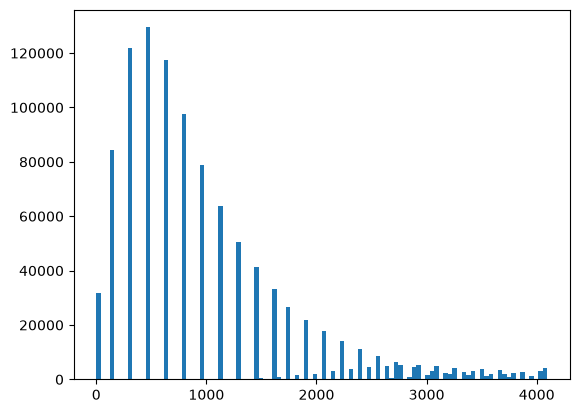

In [4]:
_ = plt.hist(img_KTR.ravel(), bins=100)
    # Note that the data is discontinuous, perhaps indicating
    # a data type conversion.

In [5]:
# calculating the mode, using stats module
the_mode1 = stats.mode(img_KTR.ravel())[0]
# calculate the mode, alternative method through bincount
the_mode2 = np.bincount(img_KTR.ravel()).argmax()

the_mode1, the_mode2

(np.uint16(480), np.int64(480))

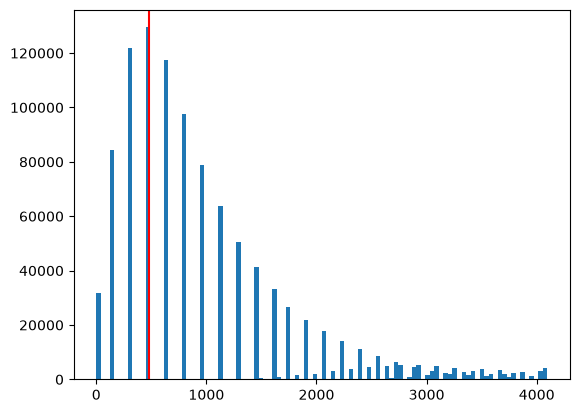

In [6]:
_ = plt.hist(img_KTR.ravel(), bins=100)
_ = plt.axvline(the_mode1, color="r")

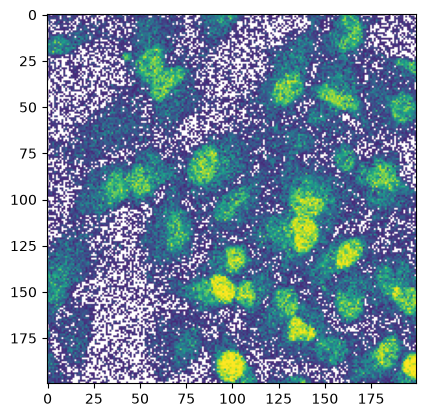

In [7]:
# Visualize what is considered background
img_KTR_crop = img_KTR[0:200, 0:200]
_ = plt.imshow(img_KTR_crop)
_ = plt.imshow(img_KTR_crop<the_mode1, alpha=(img_KTR_crop<the_mode1)*1.0, cmap="gray")

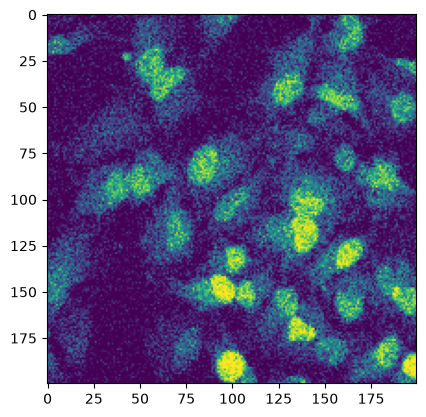

In [8]:
# Calculate the background subtracted image
img_KTR_corr = img_KTR-the_mode1
img_KTR_corr[img_KTR<the_mode1]=0

_ = plt.imshow(img_KTR_corr[0:200, 0:200])

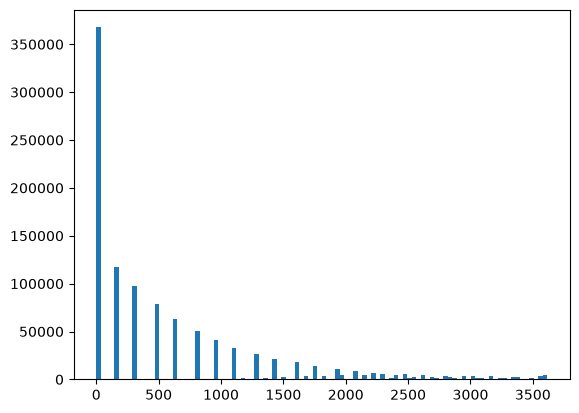

In [9]:
_ = plt.hist(img_KTR_corr.ravel(), bins=100)

## Obtaining a nuclear and cytoplasmic mask

To analyze the cytoplasm, we'll take a small ring around the nucleus.

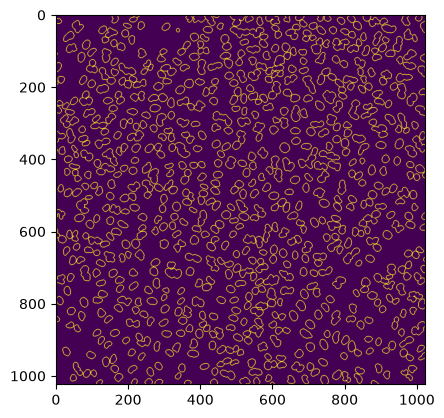

In [10]:
# Dilate to include area around the nucleus
mask_nuclei_clean_dilated = sk.morphology.dilation(mask_nuclei_clean, sk.morphology.disk(2))
# Now "subtract" the nucleus from the mask
mask_cytoplasm = mask_nuclei_clean_dilated & ~mask_nuclei_clean


_ = plt.imshow(mask_cytoplasm)

### What's the ratio?

In [11]:
overall_ratio = np.mean(img_KTR[mask_cytoplasm]) / np.mean(img_KTR[mask_nuclei])
overall_ratio

np.float64(0.5011731486917071)

### But we want single object resolution!

Let's look at how to analyze separate ROIs in an image.

# Masks, labels and regions

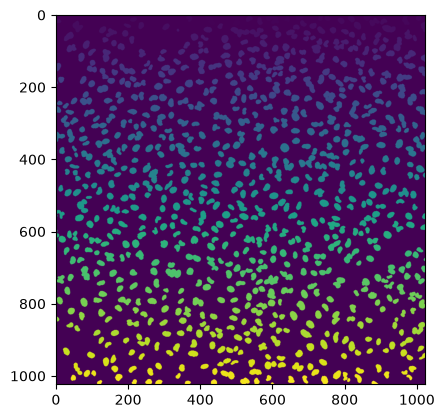

In [12]:
# Label connected components
mask_nuclei_labeled = sk.measure.label(mask_nuclei_clean, connectivity=1)
_ = plt.imshow(mask_nuclei_labeled)

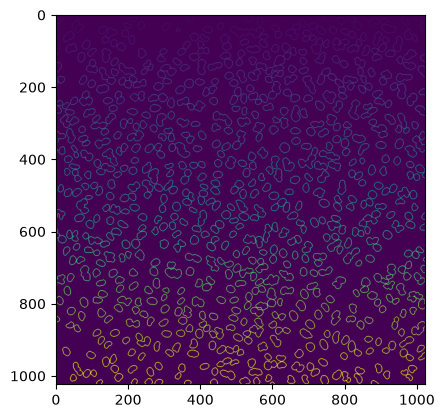

In [13]:
# Obtain labeled rings

# Dilate to include area around the nucleus
mask_cytoplasm_labeled = sk.morphology.dilation(mask_nuclei_labeled, sk.morphology.disk(2))
# Now "subtract" the nucleus from the mask
mask_cytoplasm_labeled[mask_nuclei_clean] = 0

_ = plt.imshow(mask_cytoplasm_labeled)

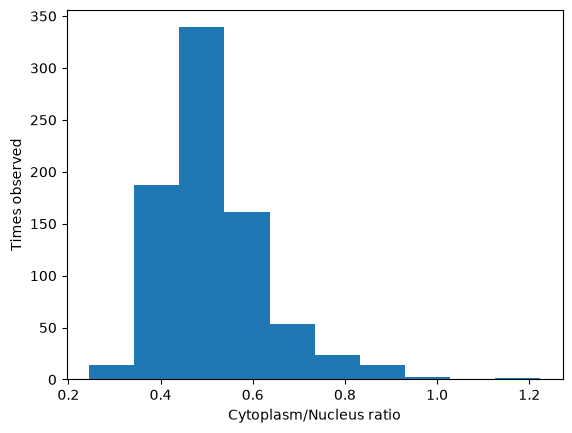

In [15]:
# Calculate ratios manually
ratios = []
for idx in range(1, np.max(mask_cytoplasm_labeled)):
    ratios.append(np.mean(img_KTR[mask_cytoplasm_labeled==idx])/np.mean(img_KTR[mask_nuclei_labeled==idx]))

# And show
_ = plt.hist(ratios)
_ = plt.xlabel("Cytoplasm/Nucleus ratio")
_ = plt.ylabel("Times observed")

### Properties of regions ("connected components")

In [ ]:
# Get properties of each of the regions
rprops_nuclei = sk.measure.regionprops(mask_nuclei_labeled)
print(rprops_nuclei[0].bbox)
print(rprops_nuclei[0].area)

(0, 156, 22, 173)
270.0


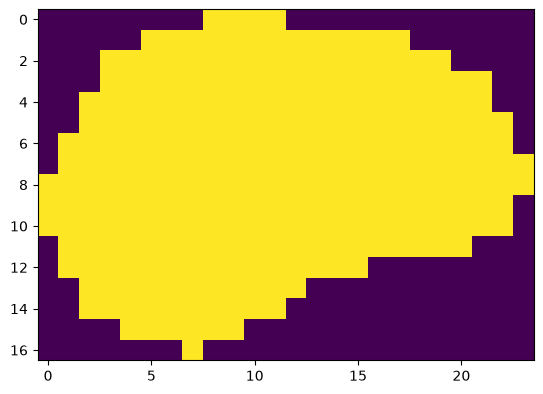

In [ ]:
# Visualizing each of the ROIs
IDX = 100
the_bbox = rprops_nuclei[IDX].bbox
_ = plt.imshow(mask_nuclei_labeled[the_bbox[0]:the_bbox[2], the_bbox[1]:the_bbox[3]])

In [ ]:
# Accessing intensity properties
rprops_KTR_nuclei = sk.measure.regionprops(mask_nuclei_labeled, intensity_image=img_KTR)
rprops_KTR_cyto = sk.measure.regionprops(mask_cytoplasm_labeled, intensity_image=img_KTR)

# Calculate the ratios
KTR_nuclei_intensities = [r.intensity_mean for r in rprops_KTR_nuclei]
KTR_cyto_intensities = [r.intensity_mean for r in rprops_KTR_cyto]
KTR_ratios = [c/n for c,n in zip(KTR_cyto_intensities, KTR_nuclei_intensities)]

# Calculate the ratios, shorter way
KTR_ratios2 = [rn.intensity_mean / cn.intensity_mean for rn, cn in zip(rprops_KTR_cyto, rprops_KTR_nuclei)]

<div align=center><img src=figures/exercise.png width=10%></div>

## Exercise: Is there a relationship between nuclear size and C/N ratio?

Can you make a scatter plot to investigate this?

<div align=center><img src=figures/exercise.png width=10%></div>

## Optional exercise: Can you measure bacterial sizes?

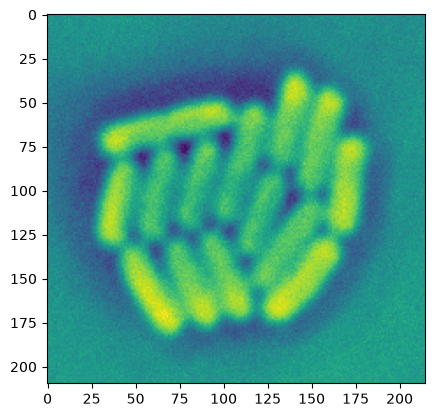

In [17]:
img_ecoli = np.invert(tiff.imread('images/microcolony_ecoli.tif'))
_ = plt.imshow(img_ecoli)

Can you think of ways to obtain one ROI (ie a labeled mask) for each of the bacteria? And then visualize the distribution of their sizes?

A labeled mask would like e.g. like the following image:

<img src="figures/bacteria_segmented.png">

Note: this is probably rather challening. Don't worry if you don't manage. 